In [1]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/code")

from parse_gtf import *
from junction2psi import *

pd.set_option('display.max_columns', None)

## First cluster MEs themselves

In [2]:
ctype_abundance_df = pd.read_csv("data/hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_Claude_marker_genes_PC1_ctype_abundance.csv", index_col=0)

In [3]:
ctype_abundance_df.head()

,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
Sample,,,,,,,,,,,,,,,,,,,
SRR21354976,-0.044285,-0.039007,-0.050520,-0.040705,-0.036997,0.054602,-0.048837,-0.040645,-0.069057,-0.030710,-0.048006,-0.040940,-0.036921,-0.051675,-0.022837,-0.028568,-0.030513,-0.034680,0.047438
SRR21354977,-0.102612,-0.096361,-0.103095,-0.087450,-0.093392,-0.068983,-0.041955,-0.080722,-0.093611,-0.087134,-0.079810,-0.038487,-0.097266,-0.070451,-0.070168,-0.033328,-0.029979,-0.098918,-0.076588
SRR21354978,0.066110,0.080648,0.040575,0.015577,0.088042,0.083732,0.137433,0.043815,0.046595,0.010198,0.050941,-0.015691,0.059116,0.059345,0.041814,-0.026107,-0.016997,0.033471,0.139094
SRR21354980,-0.062838,-0.056218,-0.059011,-0.053460,-0.050632,0.001012,-0.059529,-0.065316,-0.061609,-0.044371,-0.048646,-0.036126,-0.057911,-0.060829,-0.040492,-0.033351,-0.026356,-0.072361,0.002305
SRR21354981,0.052162,0.057345,0.042673,0.025163,0.053142,0.137448,0.118883,0.057147,0.021090,0.020718,0.044493,-0.017139,0.040288,0.014844,0.019439,-0.026080,-0.024812,0.020327,0.139889


In [4]:
abund_corr_mat = ctype_abundance_df.corr()

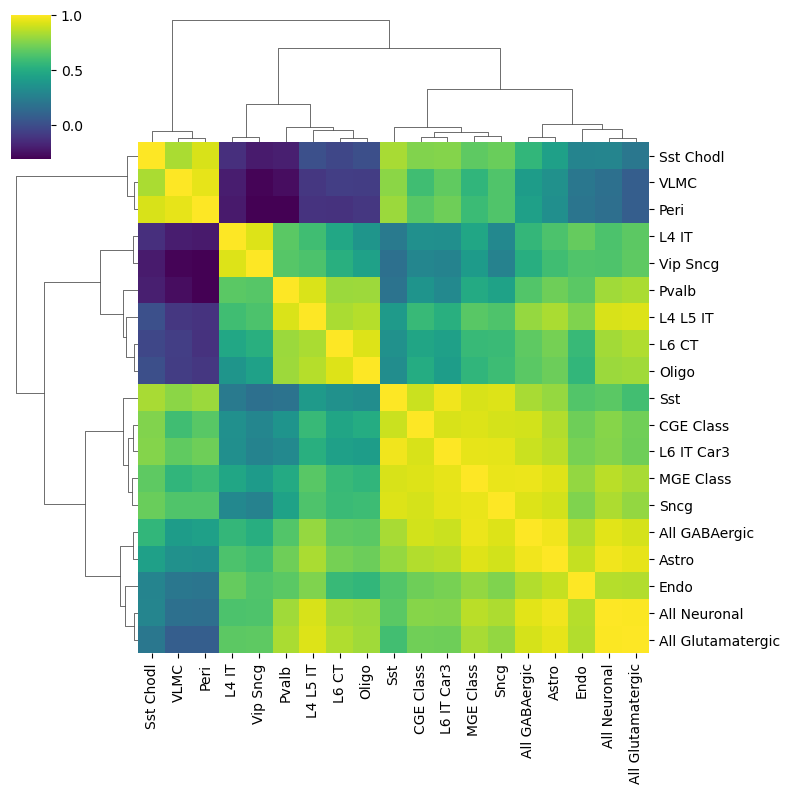

In [22]:
sns.clustermap(abund_corr_mat, cmap='viridis', method='ward', figsize=(8, 8))

## Exon counts

In [3]:
excounts_corr_df = pd.read_csv("data/corrs/hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_Claude_marker_genes_PC1_ctype_abundance_exon_counts_corr.csv", index_col=0)

In [4]:
excounts_corr_df.head()

,Gene,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
ENSMUSG00000025902_ProteinCoding_1,Sox17,0.704820,0.712606,0.685048,0.592332,0.618572,0.602368,0.550662,0.571557,0.592124,0.575845,0.487906,0.180897,0.726523,0.544935,0.704356,0.150673,0.115180,0.623887,0.608719
ENSMUSG00000025902_ProteinCoding_2,Sox17,0.706066,0.713623,0.682193,0.585042,0.617292,0.616523,0.549923,0.565232,0.586625,0.576586,0.485358,0.171957,0.727870,0.535255,0.706896,0.148453,0.112848,0.625975,0.624372
ENSMUSG00000025902_ProteinCoding_3,Sox17,0.356319,0.361247,0.318949,0.216859,0.283328,0.143687,0.271799,0.282952,0.314251,0.280414,0.232569,0.088818,0.341162,0.289881,0.304612,0.077093,0.043558,0.336717,0.149327
ENSMUSG00000025902_ProteinCoding_4,Sox17,0.465436,0.470932,0.416033,0.279767,0.347572,0.264590,0.364281,0.305548,0.367779,0.434841,0.248640,0.084684,0.432308,0.374428,0.374598,0.033845,0.005814,0.454376,0.251553
ENSMUSG00000033845_ProteinCoding_1,Mrpl15,0.896632,0.866385,0.941678,0.861636,0.937214,0.551563,0.618362,0.920686,0.910495,0.557476,0.859579,0.541323,0.950891,0.585404,0.832032,0.457440,0.467041,0.711256,0.508402


In [5]:
excounts_corr_mat = excounts_corr_df.iloc[:, 1:].corr()

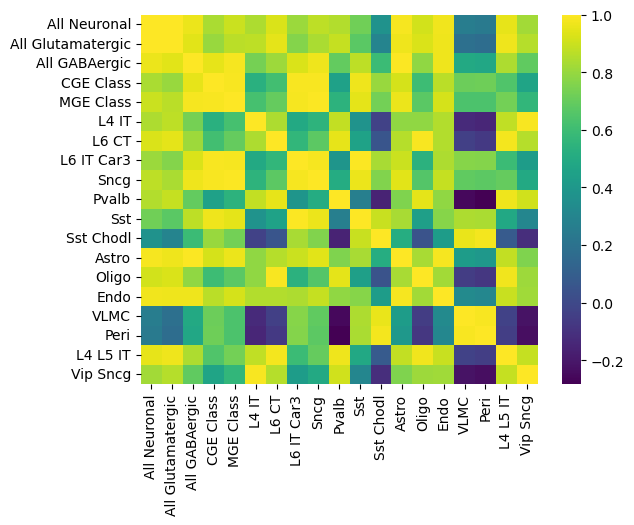

In [6]:
sns.heatmap(excounts_corr_mat, cmap='viridis')
plt.show()

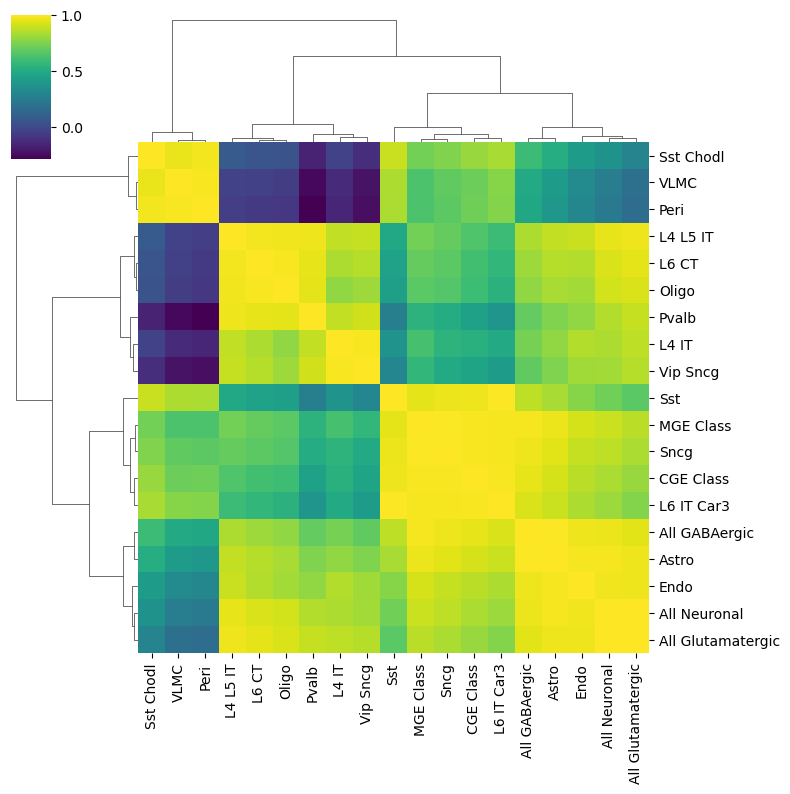

In [7]:
sns.clustermap(excounts_corr_mat, cmap='viridis', method='ward', figsize=(8, 8))

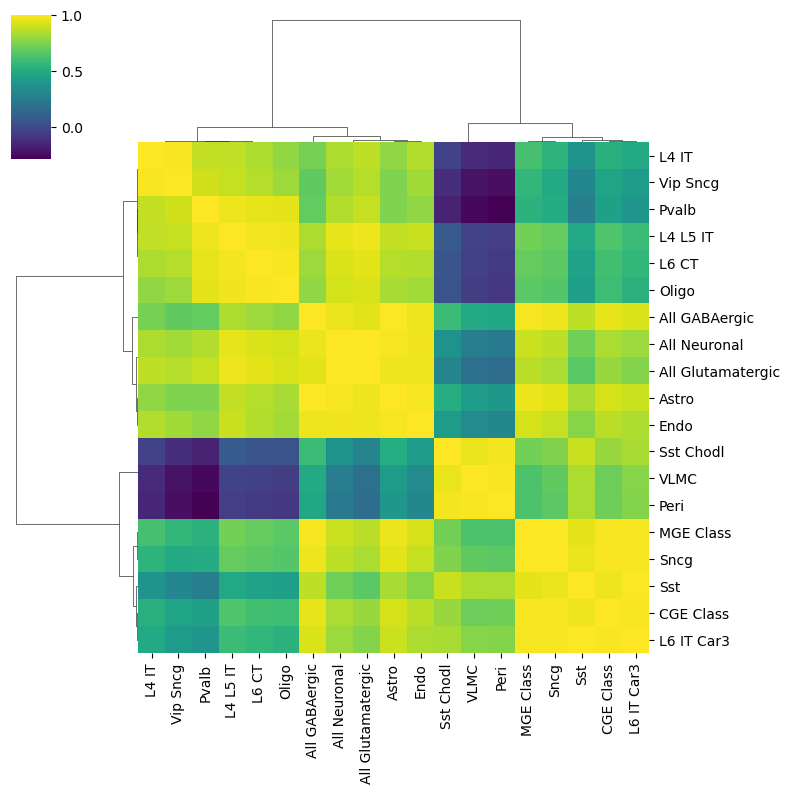

In [8]:
sns.clustermap(excounts_corr_mat, cmap='viridis', method='ward', figsize=(8, 8), metric='correlation')

## Exon PSI

In [9]:
psi_corr_df = pd.read_csv("data/corrs/hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_Claude_marker_genes_PC1_ctype_abundance_exon_PSI_corr.csv", index_col=0)

In [10]:
psi_corr_df.head()

,Gene,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
ENSMUSG00000025902_ProteinCoding_1,Sox17,0.210995,0.208977,0.225591,0.224082,0.238795,0.171566,0.110668,0.196955,0.191773,0.161382,0.182901,0.116455,0.231909,0.121474,0.200045,0.049226,0.069547,0.189688,0.189838
ENSMUSG00000025902_ProteinCoding_2,Sox17,0.210233,0.208064,0.223384,0.222319,0.236343,0.170242,0.107791,0.194713,0.189696,0.161213,0.181296,0.115070,0.229814,0.118464,0.195321,0.048092,0.069657,0.187661,0.191232
ENSMUSG00000025902_ProteinCoding_3,Sox17,0.222915,0.212486,0.232179,0.187636,0.220886,0.119220,0.136414,0.219008,0.212309,0.155742,0.183420,0.148040,0.230668,0.145625,0.219216,0.084760,0.102375,0.196474,0.130393
ENSMUSG00000025902_ProteinCoding_4,Sox17,0.297979,0.296664,0.280793,0.213693,0.256600,0.204962,0.207952,0.226028,0.242447,0.242081,0.187656,0.105264,0.278076,0.195089,0.227050,0.031827,0.045381,0.281797,0.239929
ENSMUSG00000033845_ProteinCoding_1,Mrpl15,-0.036774,-0.044344,0.010463,0.031702,0.013693,-0.044535,-0.086424,0.055253,0.023106,-0.119686,0.079011,0.116371,-0.020156,-0.085841,-0.015494,0.113653,0.119009,-0.069803,-0.050763


In [11]:
psi_corr_mat = psi_corr_df.iloc[:, 1:].corr()

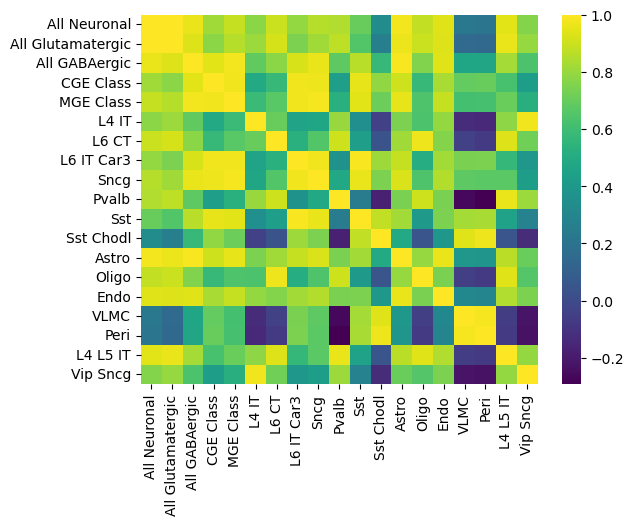

In [12]:
sns.heatmap(psi_corr_mat, cmap='viridis')
plt.show()

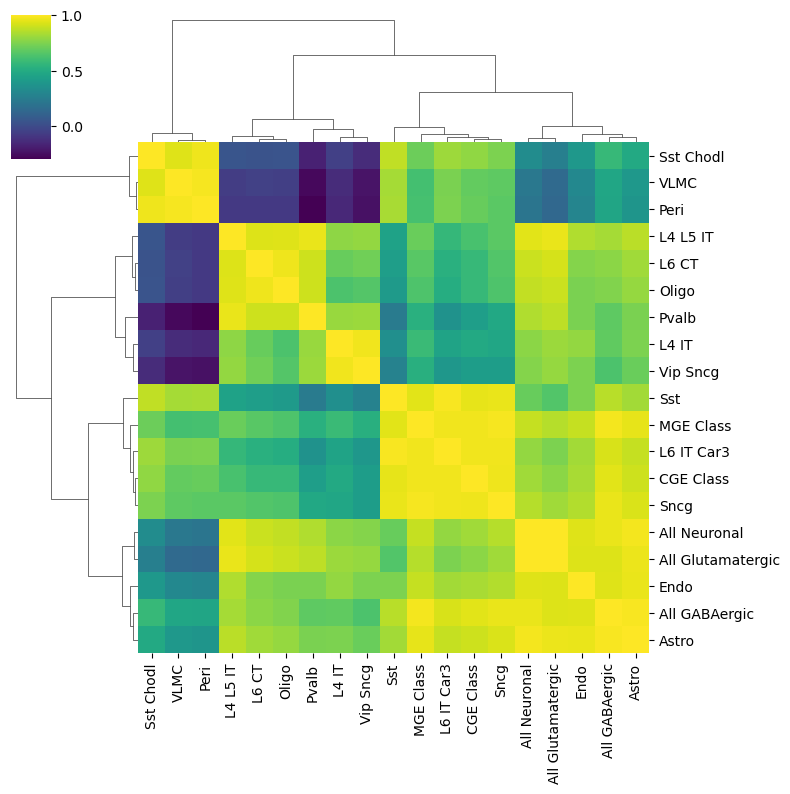

In [13]:
sns.clustermap(psi_corr_mat, cmap='viridis', method='ward', figsize=(8, 8))

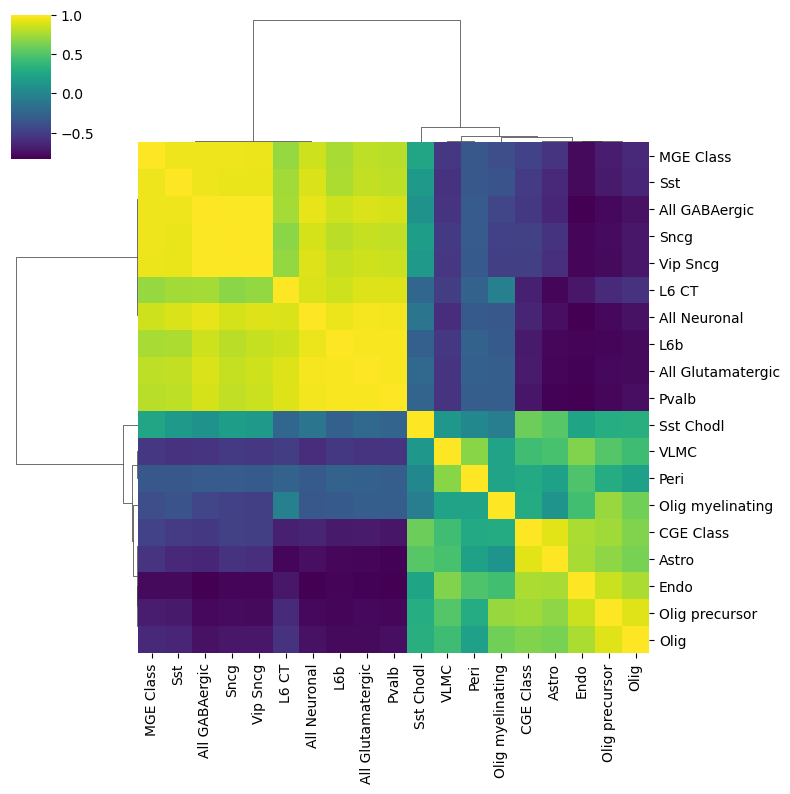

In [16]:
sns.clustermap(psi_corr_mat, cmap='viridis', method='ward', figsize=(8, 8), metric='correlation')

## Gene expression corr clustering

In [2]:
expr_corr_df = pd.read_csv("data/corrs/hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_Claude_marker_genes_PC1_ctype_abundance_gene_expr_corr.csv", index_col=0)

In [3]:
expr_corr_df.head()

,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
Gene,,,,,,,,,,,,,,,,,,,
0610005C13Rik,0.556690,0.526353,0.628878,0.564010,0.626058,0.387537,0.338188,0.635236,0.633171,0.278546,0.609607,0.420586,0.630310,0.258084,0.574153,0.386862,0.357311,0.393277,0.383543
0610006L08Rik,0.120974,0.116904,0.158819,0.226994,0.189076,0.256678,0.010762,0.202984,0.131719,0.017486,0.215986,0.153547,0.196186,0.038707,0.199845,0.093098,0.151248,0.034001,0.232925
0610009E02Rik,0.811142,0.782965,0.873884,0.823479,0.888328,0.532076,0.525484,0.873987,0.849673,0.479225,0.830166,0.559919,0.882111,0.490804,0.792256,0.452640,0.489555,0.626618,0.472594
0610009L18Rik,0.744838,0.700963,0.872749,0.895119,0.932989,0.349264,0.447919,0.955566,0.923486,0.331053,0.946740,0.740734,0.851526,0.422283,0.730444,0.663865,0.696194,0.513833,0.273351
0610010K14Rik,0.732209,0.712172,0.757924,0.655349,0.740337,0.573436,0.523384,0.726905,0.737491,0.472566,0.682825,0.375037,0.785111,0.457620,0.761761,0.389923,0.341722,0.548460,0.516871


In [4]:
expr_corr_mat = expr_corr_df.iloc[:, 1:].corr()

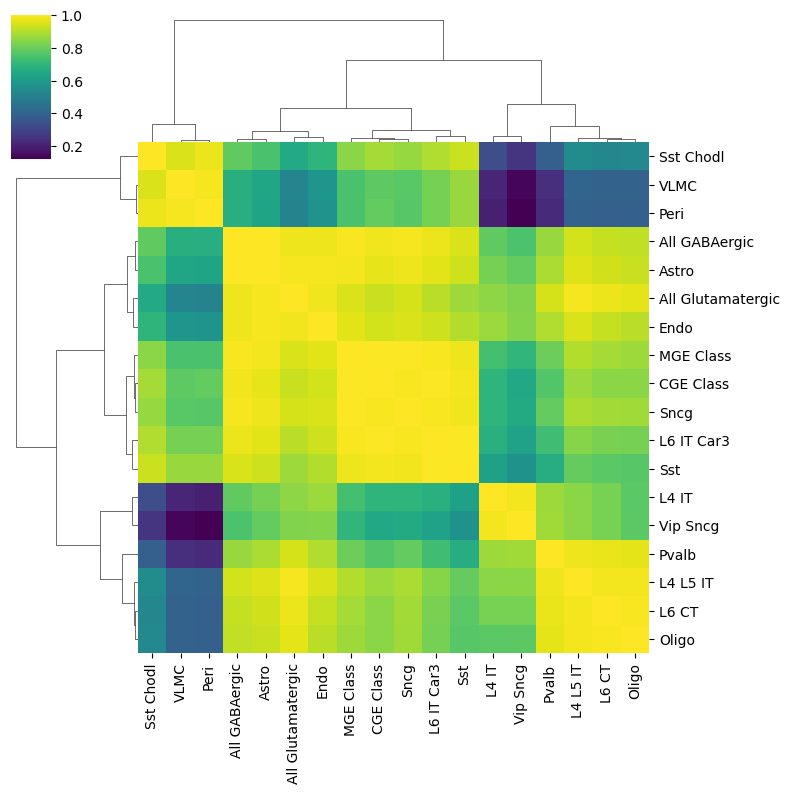

In [5]:
sns.clustermap(expr_corr_mat, cmap='viridis', method='ward', figsize=(8, 8))

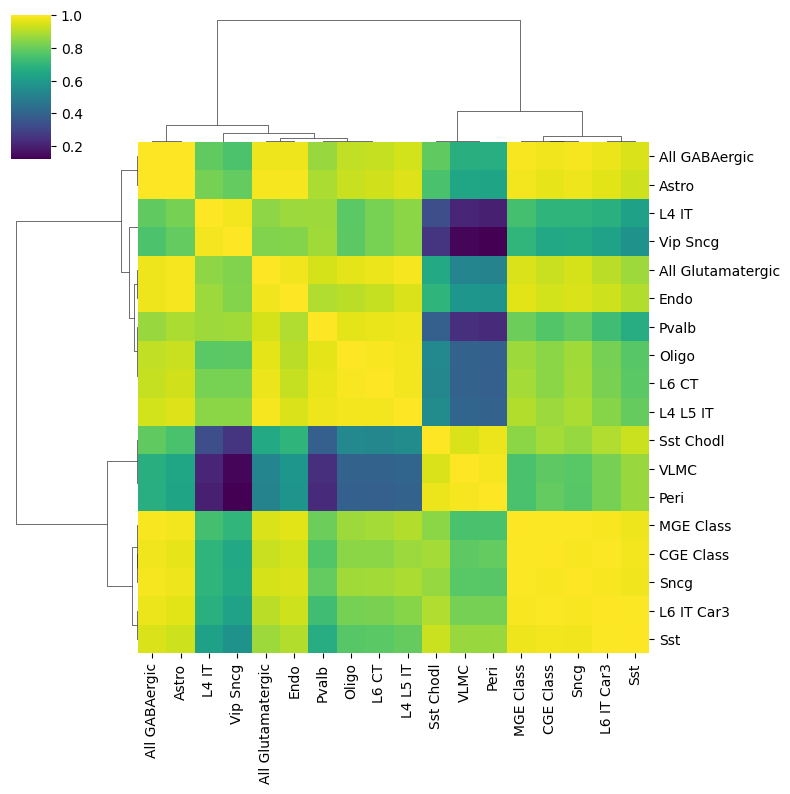

In [6]:
sns.clustermap(expr_corr_mat, cmap='viridis', method='ward', figsize=(8, 8), metric='correlation')

In [7]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(20)

,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
Gene,,,,,,,,,,,,,,,,,,,
Tcf25,0.996550,0.989559,0.951953,0.780076,0.877214,0.657889,0.812716,0.777083,0.845160,0.803866,0.684175,0.302895,0.977058,0.793564,0.864006,0.188473,0.183232,0.911512,0.655578
Sult4a1,0.995838,0.993766,0.923304,0.731314,0.836668,0.645995,0.837332,0.730704,0.810634,0.837097,0.630572,0.234470,0.958515,0.819965,0.846574,0.129731,0.116557,0.934027,0.652566
Rab6b,0.995659,0.991271,0.939191,0.753236,0.866899,0.656475,0.825640,0.761210,0.836214,0.808649,0.671361,0.276302,0.971383,0.796532,0.858146,0.165924,0.158675,0.911395,0.657622
Tango2,0.995372,0.984821,0.936559,0.754506,0.860783,0.612997,0.818503,0.756388,0.842907,0.801894,0.672333,0.299984,0.964892,0.805147,0.841575,0.181750,0.178201,0.909623,0.619211
Nars1,0.994688,0.983438,0.947866,0.772854,0.873514,0.627231,0.812448,0.772050,0.850862,0.811174,0.683585,0.301757,0.973905,0.799321,0.852067,0.203497,0.191767,0.918843,0.626679
Prkar1b,0.993749,0.981259,0.957013,0.797499,0.891351,0.621047,0.779751,0.796856,0.863895,0.771380,0.713511,0.352667,0.978019,0.766827,0.863141,0.222343,0.234836,0.892496,0.620907
Ndufs2,0.993720,0.979715,0.959706,0.802191,0.892950,0.608864,0.808661,0.802517,0.874951,0.787340,0.715112,0.347049,0.981024,0.795464,0.855867,0.246728,0.236045,0.902757,0.600279
Tuba4a,0.992333,0.992055,0.913365,0.724931,0.825248,0.643246,0.835554,0.719517,0.796749,0.821890,0.619296,0.226960,0.949852,0.822926,0.844515,0.099677,0.097783,0.929394,0.668382
Slc48a1,0.992036,0.989689,0.931294,0.756973,0.849474,0.642695,0.834149,0.745949,0.820507,0.825823,0.647445,0.263071,0.963618,0.829558,0.859068,0.151117,0.147803,0.923505,0.641927


In [8]:
expr_corr_df.sort_values("Astro", ascending=False).head(20)

,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
Gene,,,,,,,,,,,,,,,,,,,
Gpr37l1,0.968883,0.948331,0.970700,0.847816,0.930255,0.622825,0.723811,0.860089,0.900712,0.722442,0.788317,0.435123,0.994735,0.707550,0.880336,0.330752,0.334582,0.837071,0.594645
Acsbg1,0.966802,0.948277,0.961019,0.825918,0.917349,0.650554,0.714811,0.838542,0.882415,0.731743,0.767582,0.403261,0.993430,0.696762,0.883630,0.313792,0.310903,0.840501,0.621430
Tax1bp1,0.967332,0.946047,0.976723,0.858818,0.944284,0.600512,0.734764,0.873383,0.920470,0.685782,0.809805,0.456589,0.992230,0.713366,0.869295,0.363555,0.361912,0.825629,0.584494
Coq2,0.966181,0.944812,0.980776,0.865508,0.945236,0.611347,0.714755,0.884683,0.913220,0.683589,0.811836,0.465932,0.992217,0.692595,0.872353,0.361638,0.370493,0.822871,0.582754
Hepacam,0.962116,0.944652,0.969817,0.860036,0.939941,0.604210,0.736940,0.873076,0.911174,0.694006,0.806193,0.446722,0.992060,0.721987,0.870843,0.358031,0.357410,0.824630,0.574149
Idh3b,0.972035,0.950702,0.979856,0.857752,0.941249,0.600346,0.743098,0.874864,0.921235,0.691746,0.804990,0.458742,0.992017,0.716674,0.867251,0.365261,0.360666,0.829194,0.581554
Capn2,0.951446,0.931385,0.973751,0.861784,0.948684,0.629711,0.699443,0.881423,0.910099,0.676982,0.815326,0.468982,0.991725,0.669196,0.884689,0.380923,0.378169,0.801101,0.582346
Vdac2,0.971599,0.951943,0.977817,0.854040,0.937531,0.600553,0.747096,0.871208,0.915806,0.707898,0.797996,0.441290,0.991597,0.726577,0.871536,0.355544,0.346891,0.841073,0.576997
Klhdc2,0.966117,0.948343,0.976346,0.854109,0.946284,0.617326,0.726615,0.881293,0.912324,0.681987,0.809532,0.453059,0.991586,0.696912,0.870958,0.355530,0.356997,0.821168,0.591540


In [9]:
expr_corr_df.sort_values("Endo", ascending=False).head(20)

,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
Gene,,,,,,,,,,,,,,,,,,,
Ly6a,0.878978,0.890486,0.831725,0.655718,0.737311,0.736172,0.664849,0.659974,0.690718,0.744897,0.552754,0.167174,0.873258,0.641871,0.964296,0.085945,0.073660,0.812199,0.724204
Ly6c1,0.917640,0.920497,0.869776,0.689672,0.779379,0.715727,0.700261,0.696557,0.749104,0.764774,0.599216,0.211527,0.912178,0.678533,0.961045,0.129568,0.114334,0.834275,0.700669
Tgm2,0.818781,0.814059,0.851548,0.757262,0.831996,0.668264,0.529014,0.792880,0.779330,0.566612,0.722470,0.383287,0.885209,0.507178,0.958324,0.312902,0.317029,0.672727,0.596649
Vwf,0.710571,0.713171,0.705795,0.569811,0.639437,0.637160,0.436516,0.591988,0.599050,0.604227,0.511364,0.173270,0.744802,0.417931,0.938326,0.137866,0.119714,0.651905,0.571249
Flt1,0.945338,0.938414,0.916299,0.748228,0.848337,0.678466,0.703138,0.762297,0.819516,0.764259,0.678939,0.290420,0.951858,0.675968,0.934827,0.220900,0.201806,0.841857,0.625420
Igfbp7,0.922464,0.930266,0.846358,0.636962,0.739233,0.792450,0.693768,0.637317,0.685126,0.821232,0.528421,0.128288,0.902143,0.672929,0.929864,0.029572,0.018872,0.867511,0.777237
Paqr5,0.853173,0.851570,0.861407,0.738414,0.822625,0.650515,0.601409,0.770002,0.789178,0.621669,0.699470,0.328935,0.897228,0.560762,0.926791,0.305605,0.277336,0.716176,0.603574
Gjb6,0.869568,0.853090,0.904472,0.797808,0.890920,0.692299,0.564393,0.853343,0.836437,0.608508,0.787308,0.415658,0.944034,0.518851,0.926480,0.382727,0.364478,0.708838,0.627294
Slc2a1,0.918955,0.911370,0.903606,0.757517,0.844072,0.743237,0.675262,0.770969,0.795414,0.691255,0.686425,0.322868,0.940994,0.636580,0.926369,0.222428,0.220398,0.783745,0.726869


In [10]:
expr_corr_df.sort_values("Peri", ascending=False).head(20)

,All Neuronal,All Glutamatergic,All GABAergic,CGE Class,MGE Class,L4 IT,L6 CT,L6 IT Car3,Sncg,Pvalb,Sst,Sst Chodl,Astro,Oligo,Endo,VLMC,Peri,L4 L5 IT,Vip Sncg
Gene,,,,,,,,,,,,,,,,,,,
Nnat,0.186133,0.104690,0.452490,0.671354,0.605454,-0.201112,-0.106052,0.735790,0.660645,-0.304577,0.820255,0.934948,0.360858,-0.099703,0.223911,0.953859,0.990356,-0.100698,-0.289863
Dlk1,0.147584,0.060283,0.414095,0.655164,0.556356,-0.237436,-0.126985,0.671021,0.614838,-0.303633,0.762963,0.922601,0.314339,-0.095957,0.168510,0.930681,0.990235,-0.115427,-0.322719
Gm34045,0.159600,0.075569,0.414724,0.640163,0.570253,-0.202711,-0.118531,0.701431,0.625516,-0.294406,0.800270,0.882213,0.340774,-0.099530,0.214360,0.943556,0.988606,-0.113924,-0.290096
Tmem255a,0.244220,0.162645,0.505753,0.717298,0.658924,-0.149463,-0.055407,0.780127,0.701323,-0.241510,0.863430,0.942984,0.422794,-0.043114,0.282488,0.940804,0.983175,-0.040888,-0.244605
Dio3,0.147358,0.064827,0.417066,0.643027,0.570329,-0.245581,-0.140993,0.691260,0.629895,-0.333393,0.784756,0.935028,0.315771,-0.122679,0.170204,0.939835,0.975308,-0.134470,-0.335648
Rxrg,0.231415,0.151214,0.484471,0.687361,0.639015,-0.211657,-0.060696,0.762833,0.695507,-0.265547,0.847335,0.940925,0.396249,-0.046697,0.237270,0.927236,0.973046,-0.051558,-0.294070
Doc2b,0.206515,0.124840,0.476067,0.689783,0.623873,-0.176353,-0.091775,0.734183,0.672942,-0.278225,0.821358,0.954914,0.376715,-0.082134,0.232384,0.935109,0.970366,-0.084315,-0.267167
Nos1,0.276046,0.198915,0.537937,0.749330,0.680305,-0.154246,-0.036213,0.787928,0.716141,-0.226432,0.863449,0.975111,0.435506,-0.016329,0.293589,0.888996,0.969351,-0.004671,-0.234702
Gm12408,0.228216,0.145792,0.478969,0.682699,0.625843,-0.192478,-0.046792,0.741644,0.680286,-0.251707,0.828216,0.922920,0.391223,-0.032455,0.250729,0.918468,0.968650,-0.045699,-0.269984
